# 06 — Circuit Comparison: Monza vs Silverstone 2024

Compare aerodynamic parameters between the Monza 2024 low-drag package and the
Silverstone 2024 medium-high downforce package using identical methodology.

Both analyses run inline — no pkl dependencies — so this notebook is self-contained.

| Circuit | Expected package | Key corners for ClA |
|---------|-----------------|---------------------|
| Monza   | Low drag (minimum wing) | Lesmo 1&2, Curva Grande, Parabolica (~3g) |
| Silverstone | Medium-high downforce | Maggotts-Becketts complex (~4-5g) |

In [1]:
import sys
sys.path.insert(0, '..')

import os, pickle
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.segments import extract_coastdown_segments, segment_drs_state
from src.ode_fit import fit_segment, fit_segments_pooled, v_model, FitResult
from src.aero_params import air_density, car_mass, estimate_ClA, compute_CdA
from src.uncertainty import propagate_uncertainty

os.makedirs('../cache', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)
fastf1.Cache.enable_cache('../cache')

BETA_FIXED = 120.0  # N — shared prior for both circuits
MIN_R2     = 0.90

## Shared helper

Single function that runs the full coast-down + ClA pipeline for any circuit/driver.

In [2]:
def run_circuit(year, circuit, driver, sessions, lat_g_thresh, speed_thresh=150.0,
                mu_tyre=1.8, label=None):
    """
    Run coast-down ODE fit + GPS lat-g ClA estimation for one circuit.
    Returns a dict with all results.
    """
    label = label or f'{circuit} {year}'
    print(f'\n=== {label} ===')

    # --- coast-down segments ---
    all_results: list[FitResult] = []
    all_segs_plot = []
    rho_vals = []

    for sname in sessions:
        try:
            sess = fastf1.get_session(year, circuit, sname)
            sess.load(telemetry=True, weather=True)
        except Exception as e:
            print(f'  Skipping {sname}: {e}')
            continue

        rho_s = air_density(sess.weather_data['AirTemp'].mean(),
                            sess.weather_data['Pressure'].mean())
        rho_vals.append(rho_s)

        laps = sess.laps.pick_drivers(driver)
        laps = laps[laps['LapNumber'] > 1].copy()
        n_before = len(all_results)

        for _, lap in laps.iterrows():
            lap_num = int(lap['LapNumber'])
            m = car_mass(lap_num)
            try:
                tel = lap.get_telemetry()
            except Exception:
                continue
            segs = extract_coastdown_segments(
                tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0)
            for seg in segs:
                drs_open = segment_drs_state(seg)
                r = fit_segment(seg, m, rho_s, drs_open, lap_num, beta_fixed=BETA_FIXED)
                if r is not None and r.r2 >= MIN_R2:
                    all_results.append(r)
                    all_segs_plot.append((seg, r))

        print(f'  {sname}: +{len(all_results) - n_before} segments')

    rho = float(np.mean(rho_vals)) if rho_vals else float('nan')
    print(f'  Total segments: {len(all_results)},  ρ = {rho:.4f} kg/m³')

    if len(all_results) < 2:
        print(f'  WARNING: fewer than 2 segments — pooled fit skipped')
        alpha_p     = float(np.median([r.alpha for r in all_results])) if all_results else float('nan')
        alpha_std_p = float('nan')
    else:
        segs_p = [seg for seg, _ in all_segs_plot]
        ms_p   = [r.m          for _, r in all_segs_plot]
        drs_p  = [r.drs_open   for _, r in all_segs_plot]
        lap_p  = [r.lap_number for _, r in all_segs_plot]
        pooled = fit_segments_pooled(segs_p, ms_p, drs_p, lap_p,
                                     seed_results=all_results, beta_fixed=BETA_FIXED)
        if pooled:
            all_results  = pooled
            all_segs_plot = [(seg, pooled[i]) for i, (seg, _) in enumerate(all_segs_plot)]
            alpha_p      = pooled[0].alpha
            alpha_std_p  = pooled[0].alpha_std
            print(f'  Pooled α = {alpha_p:.4f} ± {alpha_std_p:.4f}  '
                  f'composite 2α/ρ = {2*alpha_p/rho:.3f} m²')
        else:
            alpha_p     = float(np.median([r.alpha for r in all_results]))
            alpha_std_p = float(np.std([r.alpha for r in all_results]))
            print(f'  Pooled fit failed; median α = {alpha_p:.4f}')

    # --- ClA from GPS lat-g (FP2 preferred, fall back to first session) ---
    ClA_per_lap = []
    clA_sname   = sessions[1] if len(sessions) > 1 else sessions[0]
    try:
        clA_sess = fastf1.get_session(year, circuit, clA_sname)
        clA_sess.load(telemetry=True, weather=True)
        clA_laps = clA_sess.laps.pick_drivers(driver)
        clA_laps = clA_laps[(clA_laps['LapNumber'] > 2) &
                             (clA_laps['LapNumber'] < clA_laps['LapNumber'].max())]
        rho_cla = air_density(clA_sess.weather_data['AirTemp'].mean(),
                              clA_sess.weather_data['Pressure'].mean())
        for _, lap in clA_laps.iterrows():
            m = car_mass(int(lap['LapNumber']))
            try:
                tel = lap.get_telemetry()
            except Exception:
                continue
            ClA_med, _ = estimate_ClA(
                tel, m, rho_cla, mu=mu_tyre,
                min_speed_kmh=speed_thresh,
                min_lat_g=lat_g_thresh,
                min_throttle=50.0,
            )
            if np.isfinite(ClA_med) and 0.5 < ClA_med < 10.0:
                ClA_per_lap.append(ClA_med)
    except Exception as e:
        print(f'  ClA estimation failed: {e}')

    ClA         = float(np.median(ClA_per_lap))  if ClA_per_lap else float('nan')
    ClA_std_val = float(np.std(ClA_per_lap))     if ClA_per_lap else float('nan')
    print(f'  ClA = {ClA:.3f} ± {ClA_std_val:.3f} m²  ({len(ClA_per_lap)} lap estimates)')

    # --- CdA via Monte Carlo ---
    Crr_vals = [r.beta / (r.m * 9.81) for r in all_results]
    mc = propagate_uncertainty(all_results, rho, ClA, ClA_std_val) if all_results else None

    return {
        'label':      label,
        'rho':        rho,
        'driver':     driver,
        'n_segments': len(all_results),
        'alpha':      alpha_p,
        'alpha_std':  alpha_std_p,
        'composite':  2 * alpha_p / rho,
        'ClA':        ClA,
        'ClA_std':    ClA_std_val,
        'Crr':        float(np.median(Crr_vals)) if Crr_vals else float('nan'),
        'CdA':        mc.CdA_mean if mc else float('nan'),
        'CdA_std':    mc.CdA_std  if mc else float('nan'),
        'mc':         mc,
        'results':    all_results,
        'segs_plot':  all_segs_plot,
    }

## Driver survey — Silverstone 2024

Driver 14 (ALO) is the reference at Monza. Survey Silverstone to find the driver
with the most coast-down segments — typically the team that runs the most laps in FP.

In [3]:
SIL_SURVEY_CACHE = '../results/survey_cache_silverstone.pkl'

if os.path.exists(SIL_SURVEY_CACHE):
    with open(SIL_SURVEY_CACHE, 'rb') as f:
        sil_survey = pickle.load(f)
    print('Loaded Silverstone survey from cache.')
else:
    rows = []
    for sname in ['FP1', 'FP2', 'FP3']:
        try:
            sess = fastf1.get_session(2024, 'British', sname)
            sess.load(telemetry=True, weather=True)
        except Exception as e:
            print(f'Could not load {sname}: {e}')
            continue
        rho_s = air_density(sess.weather_data['AirTemp'].mean(),
                            sess.weather_data['Pressure'].mean())
        for driver in sess.drivers:
            try:
                laps = sess.laps.pick_drivers(driver)
                laps = laps[laps['LapNumber'] > 1]
            except Exception:
                continue
            n = 0
            for _, lap in laps.iterrows():
                m = car_mass(int(lap['LapNumber']))
                try:
                    tel = lap.get_telemetry()
                except Exception:
                    continue
                for seg in extract_coastdown_segments(
                        tel, min_duration=0.5, min_speed_kmh=120.0, throttle_threshold=5.0):
                    r = fit_segment(seg, m, rho_s, False, int(lap['LapNumber']))
                    if r is not None and r.r2 >= MIN_R2:
                        n += 1
            if n > 0:
                rows.append({'session': sname, 'driver': driver, 'n_segments': n})

    sil_survey = (pd.DataFrame(rows)
                  .groupby('driver')
                  .agg(total_segments=('n_segments', 'sum'))
                  .sort_values('total_segments', ascending=False)
                  .reset_index())
    with open(SIL_SURVEY_CACHE, 'wb') as f:
        pickle.dump(sil_survey, f)
    print('Survey complete. Cached.')

print(sil_survey.head(10).to_string(index=False))
sil_driver = sil_survey.iloc[0]['driver']
print(f'\nSelected Silverstone driver: {sil_driver}  '
      f'({int(sil_survey.iloc[0]["total_segments"])} segments)')
print(f'Monza reference driver:     14  (ALO)')

Loaded Silverstone survey from cache.
driver  total_segments
    18               2
    27               1
     3               1

Selected Silverstone driver: 18  (2 segments)
Monza reference driver:     14  (ALO)


## Run both circuits

In [4]:
monza = run_circuit(
    year=2024, circuit='Monza', driver='14',
    sessions=['FP1', 'FP2', 'FP3'],
    lat_g_thresh=2.5,   # Monza peaks ~3.0–3.7g; 2.5g selects near-limit apices
    speed_thresh=150.0,
    label='Monza 2024',
)

silverstone = run_circuit(
    year=2024, circuit='British', driver=sil_driver,
    sessions=['FP1', 'FP2', 'FP3'],
    lat_g_thresh=3.5,   # Maggotts-Becketts peaks ~4–5g; 3.5g is reliably at limit
    speed_thresh=180.0, # Maggotts entry ~260 km/h; high threshold keeps it clean
    label='Silverstone 2024',
)

core           INFO 	Loading data for Italian Grand Prix - Practice 1 [v3.8.3]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for track_status_data


...

req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 20 drivers: ['1', '2', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '44', '55', '63', '77', '81']


  ClA = 3.882 ± 0.561 m²  (13 lap estimates)


## Comparison

In [5]:
results = [monza, silverstone]

print(f'\n{"":30} {"Monza 2024":>18} {"Silverstone 2024":>18} {"Ratio S/M":>12}')
print('-' * 82)

def _row(label, key, key_std=None, fmt='.3f'):
    m_val = monza[key]
    s_val = silverstone[key]
    ratio = s_val / m_val if (np.isfinite(m_val) and np.isfinite(s_val) and m_val != 0) else float('nan')
    m_str = f'{m_val:{fmt}}'
    s_str = f'{s_val:{fmt}}'
    if key_std:
        m_str += f' ± {monza[key_std]:{fmt}}'
        s_str += f' ± {silverstone[key_std]:{fmt}}'
    print(f'{label:30} {m_str:>18} {s_str:>18} {ratio:>12.2f}')

_row('Air density ρ (kg/m³)',   'rho',       fmt='.4f')
_row('Segments',                'n_segments', fmt='d')
_row('Pooled α (N·s²/m²)',     'alpha',     'alpha_std')
_row('Composite 2α/ρ (m²)',    'composite')
_row('Crr',                    'Crr',        fmt='.4f')
_row('ClA (m²)',               'ClA',       'ClA_std')
_row('CdA (m²)',               'CdA',       'CdA_std')

if np.isfinite(monza['CdA']) and np.isfinite(silverstone['CdA']):
    delta_CdA = silverstone['CdA'] - monza['CdA']
    delta_ClA = silverstone['ClA'] - monza['ClA']
    print(f'\nΔCdA  Silverstone − Monza = {delta_CdA:+.3f} m²  (more drag from higher wing angle)')
    print(f'ΔClA  Silverstone − Monza = {delta_ClA:+.3f} m²  (more downforce)')
    if np.isfinite(delta_ClA) and delta_CdA != 0:
        print(f'ΔClA/ΔCdA efficiency     = {delta_ClA/delta_CdA:.1f}  (downforce gained per unit drag added)')


                                       Monza 2024   Silverstone 2024    Ratio S/M
----------------------------------------------------------------------------------
Air density ρ (kg/m³)                      1.1343             1.1925         1.05
Segments                                       14                  7         0.50
Pooled α (N·s²/m²)                  0.800 ± 0.002      1.076 ± 0.005         1.35
Composite 2α/ρ (m²)                         1.410              1.805         1.28
Crr                                        0.0131             0.0131         1.00
ClA (m²)                            3.358 ± 0.629      3.882 ± 0.561         1.16
CdA (m²)                            1.366 ± 0.009      1.754 ± 0.011         1.28

ΔCdA  Silverstone − Monza = +0.388 m²  (more drag from higher wing angle)
ΔClA  Silverstone − Monza = +0.524 m²  (more downforce)
ΔClA/ΔCdA efficiency     = 1.4  (downforce gained per unit drag added)


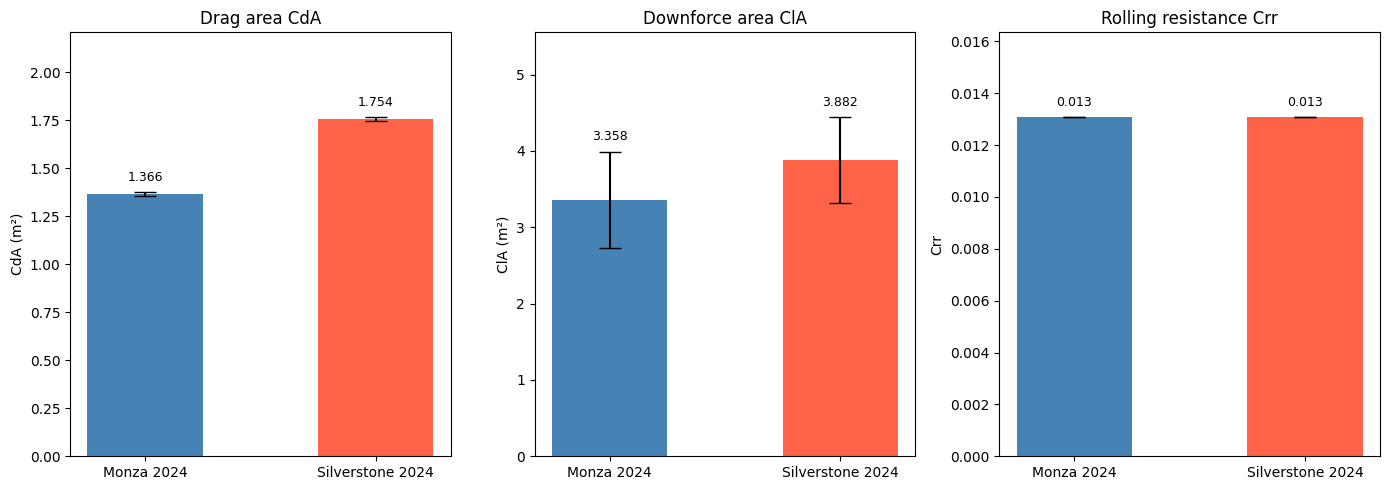

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
labels  = ['Monza 2024', 'Silverstone 2024']
colors  = ['steelblue', 'tomato']

for ax, key, key_std, ylabel, title in [
    (axes[0], 'CdA', 'CdA_std', 'CdA (m²)',  'Drag area CdA'),
    (axes[1], 'ClA', 'ClA_std', 'ClA (m²)',  'Downforce area ClA'),
    (axes[2], 'Crr', None,      'Crr',        'Rolling resistance Crr'),
]:
    vals = [r[key]     for r in results]
    errs = [r[key_std] for r in results] if key_std else [0, 0]
    bars = ax.bar(labels, vals, yerr=errs, capsize=8, color=colors, width=0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ymax = max(v + e for v, e in zip(vals, errs)) * 1.25
    ax.set_ylim(0, ymax)
    for bar, v, e in zip(bars, vals, errs):
        if np.isfinite(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    v + (e if e else 0) + ymax * 0.02,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/06_circuit_comparison.png', dpi=150)
plt.show()

## Residual autocorrelation check

In [7]:
from statsmodels.stats.stattools import durbin_watson

for res_set in [monza, silverstone]:
    dw_vals = []
    for seg, fit in res_set['segs_plot']:
        t     = seg['t'].values - seg['t'].values[0]
        v_meas = seg['Speed'].values / 3.6
        v_pred = v_model(t, fit.alpha, fit.beta, fit.P_mgu, fit.v0, fit.m)
        dw_vals.append(durbin_watson(v_meas - v_pred))
    mean_dw = float(np.mean(dw_vals)) if dw_vals else float('nan')
    flag = '✓' if 1.5 <= mean_dw <= 2.5 else '⚠ engine-braking autocorrelation'
    print(f"{res_set['label']:20}  segments={res_set['n_segments']}  "
          f"mean DW={mean_dw:.2f}  {flag}")

Monza 2024            segments=14  mean DW=0.35  ⚠ engine-braking autocorrelation
Silverstone 2024      segments=7  mean DW=0.49  ⚠ engine-braking autocorrelation
